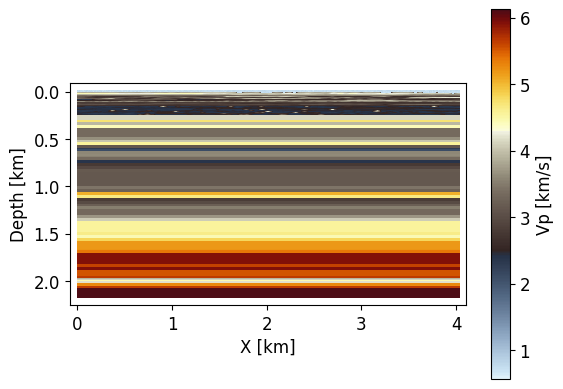

In [1]:
import numpy as np
from frequensolve import *

project_path = "./scratch/ex_03/"

project = Project(
    name = "project",
    pretty_name = "Desert Simulation",
    path = project_path,
    load_if_exists = False
)

sim = project.new_simulation(
    name = "desert",
    physics = "acoustic",
    dimension = 2,
    f0 = 1.0,
)
project += sim

# --- Model ---
model = LayeredModel(
    dimension = 2, 
    x_limits = [0.0, 4.029],
)

model.add_surface(
    name = "dune_topo",
    # z = "desert_data/dune_topo.nc",
    z = -0.01,
    z_ref = 0.0,
)

model.add_layer(
    name = "sand",
    properties = { 
        "Vp" : 0.731, 
        "Vs" : 0.3,
        "Rho": 1.6,
        "Qp" : 40.0 * PowerLawDispersion(f0 = 10.0, alpha = 0.9),
        "Qs" : 40.0 * TablulatedDispersion([1.0, 10.0],[10.0, 20.0],extrapolation = "nearest"),
    }
)
                
model.add_surface(
    name = "buried_topo",
    z = "desert_data/buried_topo.nc",
    z_ref = 0.025,
)

model.add_layer(
    name = "near_surface",
    properties = { 
        "Vp" : "desert_data/Vp_near.nc" * PowerLawDispersion(f0 = 10.0, alpha = 0.5),
        "Vs" : "desert_data/Vs_near.nc",
        "Rho": "desert_data/Rho_near.nc",
        "Qp" : 60.0,
        "Qs" : 60.0,
    }
)

model.add_surface(z = 0.483e-1)
model.add_surface(z = 0.972e-1)
model.add_surface(z = 1.512e-1)
model.add_surface(z = 1.941e-1)
model.add_surface(z = 2.508e-1)

model.add_layer(
    name = "sub_surface",
    properties = { 
        "Vp" : "desert_data/Vp1D.nc",
        "Vs" : "desert_data/Vs1D.nc",
        "Rho": "desert_data/Rho1D.nc",
        "Qp" : 80.0,
        "Qs" : 80.0
    }
)

# Add lower surfaces
z_list = [ 3.9e-1, 4.791e-1, 5.712e-1, 6.312e-1, 6.99e-1, 
          7.551e-1, 9.981e-1, 1.059e0, 1.1211e0, 1.3032e0, 1.3662e0, 
          1.548e0, 1.7052e0, 1.8201e0, 1.881e0, 1.9692e0, 2.016e0,
          2.067e0, 2.1747e0 ]
for z in z_list:
    model.add_surface(z = z)

import xarray as xr
sand = model.layers["sand"]
grid = xr.DataArray(
    dims = ["x", "z"], 
    coords = {"x": np.linspace(0.0, 4.029, 501),
              "z": np.linspace(-0.01, 0.2, 101)}
)       
sand.perturb(
    property = ["Vs", "Vp", "Rho"],
    std = 0.05,
    L0 = 0.01,
    nu = 0.5,
    anisotropy = [1.0, 1.0],
    xarr = grid,
    seed = 12
)

sim += model
model.plot(
    property = "Vp",
    aspect = "equal",
    surfaces = False,
    cmap = RdYlBu_r
)

# --- Mesh ---
mesh = model.hex_mesh_generator(n = [4, 4])
sim += mesh
sim.mesh.set_adapt(
    min_epw = 2.0,
    adapt_sources = 2,
    f_low = 5.0,
    f_med = 8.0
)

In [2]:
# --- Boundary Conditions ---

BCs = BoundaryConditionManager(label_type = "geometric")

# # Free surface BC
# BCs += BoundaryCondition(
#     name = "free_surface",
#     kind = "neumann",
#     boundaries = ["z_min"]
# )

# Perfectly matched layer (absorbing boundary condition)
BCs += BoundaryCondition(
    name = "pml",
    kind = "pml",
    boundaries = ["x_min", "x_max", "z_max", "z_min"],
    pml_wavelengths = 1.3,
    pml_exponent = 3.0,
    pml_constant = 40.0
)
sim += BCs

# --- Acquisition ---

acq = Acquisition()

# Source
# acq.add_source_group(
#     kind = "vector",
#     coords = [[4.023/2, 0.0]],
#     direction = [0.0, 1.0],
#     frame = "reference"
# )
acq.add_source_group(
    kind = "scalar",
    coords = [[4.023/2, 0.0]],
    frame = "reference"
)

# Receivers
device = ReceiverNode(name = "geophone")
device.add_component("p","pressure")
# device.add_component("u_z","displacement",[0.0, 1.0])
# device.add_component("u_x","displacement",[1.0, 0.0])

coords = [ [x, 0.0] for x in np.linspace(0.0, 4.023, 1001)]

acq.add_receiver_group(
    name = "surface_geophones",
    device = device,
    coords = coords,
    frame = "reference",
    post_process = False,
)
sim += acq

# --- Discretization ---

method = Discretization(
    order = {
        "x" : 6,
        "z" : 6,
    },
)
sim += method

# --- Solver Options ---

solver = SolverConfig(
    solve_on = "final",
    max_iter = 300,
    grids = 4,
    tolerance = 5.0e-5
)
sim += solver

# --- Outputs ---

out = OutputManager()
# out += ParaviewOutput(
#     name = "desert", 
#     fields = ["displacement", "pressure"], 
#     upscale = 1,
#     post_process = False,
# )
sim += out

project.save()

PosixPath('/Users/jacobbadger/omnirepo/FrequenSolve/examples/scratch/ex_03/project.json')

20 20.0


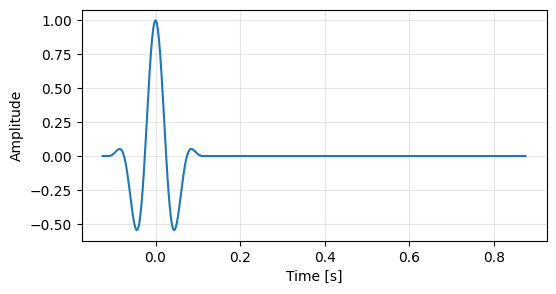

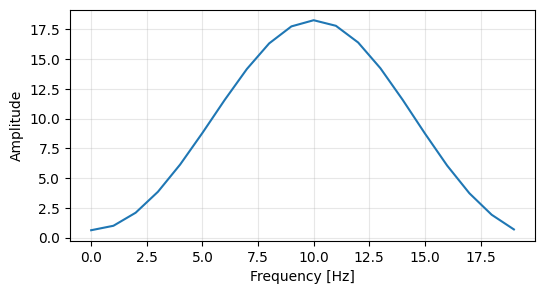

surface_geophones
  Receivers	: 1 - 1001
  Shot		: 1
  Components	: ['p']
  Frequencies	: 1.00 - 20.00 Hz (Δf=0.25)
  Window	: 0.00 - 4.00 s




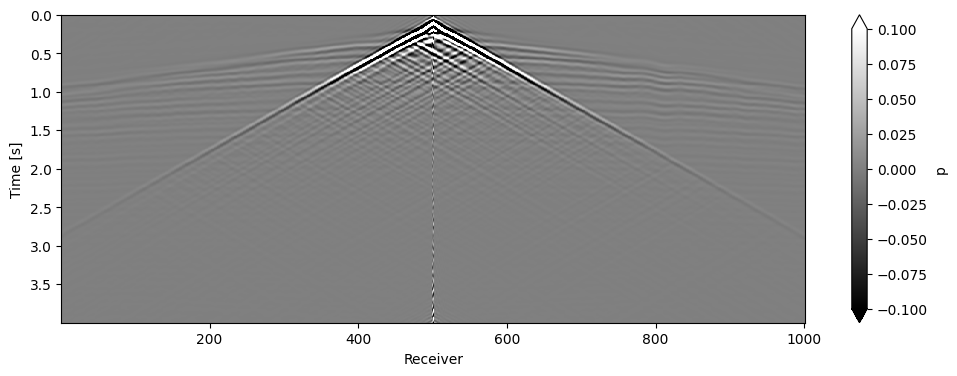

In [ ]:
# --- Connect to site ---
   
site = "local"

if site == "local":
    site = LocalSite()
elif site == "stampede3":
    site = Stampede3Site(
        rel_path = "problems/ex_01/",
        default_queue = "skx-dev"
    )
else:
    raise ValueError(f"Site {site} not supported; specify a valid site from options above.")
site.sync(project)

job = TimeDomainJob(
    name = "job",
    simulation = sim,
    f_min = 1.0,
    f_max = 20.0,
    T_max = 4.0
)

if site.provisioned:
    pass
    site.submit(job)
else:
    site.submit_SLURM(
        job = job,
        nodes = 1,
        procs_per_node = 12,
        procs_per_task = 1,
        queue = "skx-dev",
        duration = "00-00:01:00",
    )

    # Wait for SLURM job to complete
    site.wait_completion(job)

# Get results from the site
trace_db = site.fetch_traces(job, upscale = 4)
wavelet = KlauderWavelet(
    f = [5.0, 15.0],
    window = ("blackman", 0.25),
    center = 0.125
)
wavelet.plot(f_max = 20.0)

print(trace_db)
for group in trace_db.groups:
    for shot in trace_db.shots(group):
        for comp in trace_db.components(group):
            td = trace_db.read_TD(group, comp, shot, wavelet, upscale = 4)
            plt.figure(figsize=(12, 4))
            plot = td.plot(
                vmin = -.1, 
                vmax = .1, 
                y = "time", 
                yincrease = False,
                cmap = "gray"
            )
            plt.show()